## Fashion-MNIST Dataset: Overview and Explanation

#### What is Fashion-MNIST?

Fashion-MNIST is a widely used machine learning dataset designed to help models learn to recognize different types of fashion items from images. It was created by Zalando and contains images of various articles of clothing and accessories.

#### Key Features

- **Total Images:** 60,000 examples in the training set.
- **Image Format:** Each image is 28x28 pixels, grayscale (black-and-white).
- **Pixel Values:** Every pixel has an integer value from 0 to 255, where:
  - **0** represents white (lightest).
  - **255** represents black (darkest).
  - Higher numbers mean darker pixels.
- **Data Structure:**  
  - The first data column is the **class label** (what type of clothing it is).
  - The remaining columns are the pixel values that make up the image.

#### Class Labels and Clothing Types

Each image is labeled with a number from 0 to 9, identifying the type of fashion product:

| Label | Fashion Product |
|-------|----------------|
| 0     | T-shirt/top    |
| 1     | Trouser        |
| 2     | Pullover       |
| 3     | Dress          |
| 4     | Coat           |
| 5     | Sandal         |
| 6     | Shirt          |
| 7     | Sneaker        |
| 8     | Bag            |
| 9     | Ankle boot     |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

**Load data**

Train data

https://github.com/insop/Fashion-MNIST-csv/raw/refs/heads/master/images_train.csv.gz

Train labels

https://github.com/insop/Fashion-MNIST-csv/raw/refs/heads/master/labels_train.csv.gz

Test data

https://github.com/insop/Fashion-MNIST-csv/raw/refs/heads/master/images_test.csv.gz

Test labels

https://github.com/insop/Fashion-MNIST-csv/raw/refs/heads/master/labels_test.csv.gz



In [3]:
X_train = pd.read_csv(r'C:\Users\DELL\Desktop\Classes\ML_Batch_474_477_482\KNN\images_train.csv')
X_train.tail()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.341,0.342,0.343,0.344,0.345,0.346,0.347,0.348,0.349,0.350
59994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,66,54,50,5,0,1,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
28*28

784

In [4]:
X_train.shape

(59999, 784)

In [5]:
X_train.columns

Index(['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9',
       ...
       '0.341', '0.342', '0.343', '0.344', '0.345', '0.346', '0.347', '0.348',
       '0.349', '0.350'],
      dtype='object', length=784)

### Renaming columns names

In [7]:
for i, name in enumerate(X_train.columns):
  X_train.rename(columns = {name:f'feature_{i}'}, inplace = True)

In [8]:
X_train.columns

Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9',
       ...
       'feature_774', 'feature_775', 'feature_776', 'feature_777',
       'feature_778', 'feature_779', 'feature_780', 'feature_781',
       'feature_782', 'feature_783'],
      dtype='object', length=784)

In [9]:
y_train = pd.read_csv(r'C:\Users\DELL\Desktop\Classes\ML_Batch_474_477_482\KNN//labels_train.csv')
y_train.head()

,9
0,0
1,0
2,3
3,0
4,2


In [10]:
y_train.columns

Index(['9'], dtype='object')

In [11]:
y_train.rename(columns = {'9':'label'}, inplace = True)

In [12]:
y_train.columns

Index(['label'], dtype='object')

### Exploratory data analysis

<Axes: xlabel='label', ylabel='count'>

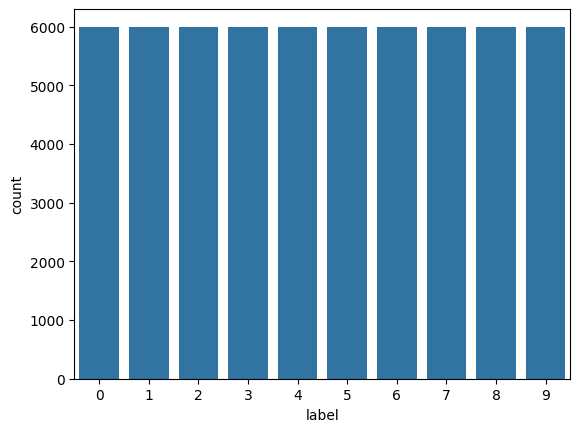

In [13]:
sns.countplot(data = y_train, x = 'label')

#### Visualize all categories of dataset

In [15]:
item_dictionary = {0: 't-shirt/top', 1: 'trouser',
                   2: 'pullover', 3: 'dress',
                   4: 'coat', 5: 'sandal',
                   6: 'shirt', 7: 'sneaker',
                   8: 'bag', 9: 'ankle_boot'}

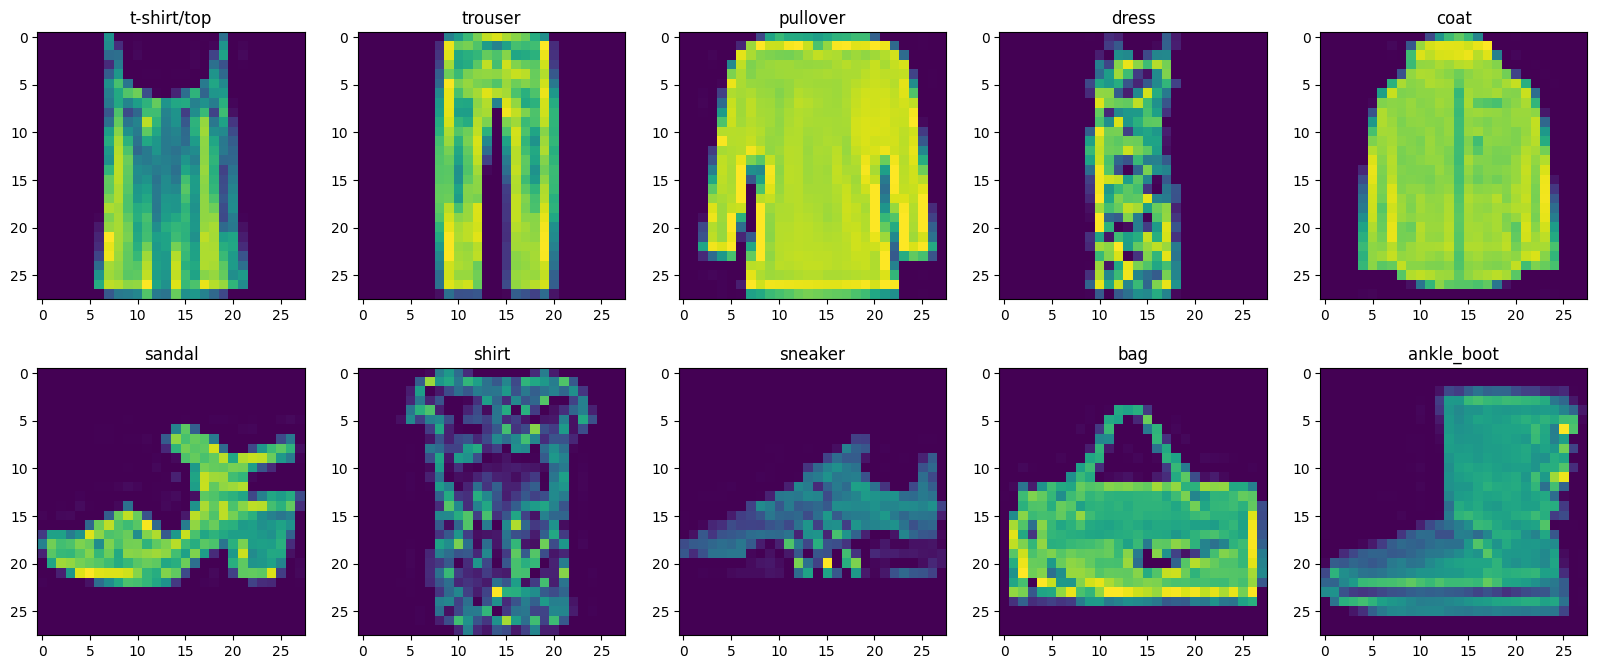

In [27]:
idx = y_train.groupby('label').sample(n = 1).index
fig, ax = plt.subplots(2, 5, figsize = (20, 8))
axs = ax.flatten()
for i, ind in enumerate(idx):
  axs[i].imshow(X_train.iloc[ind, :].values.reshape(28, 28))
  axs[i].set_title(item_dictionary.get(y_train.loc[ind, 'label']))

## Scaling

In [35]:
minmax = MinMaxScaler()
X_train_transformed = minmax.fit_transform(X_train)
X_train_transformed

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(59999, 784))

## PCA

In [36]:
pca = PCA(n_components=2)
X_train_low_dim = pca.fit_transform(X_train_transformed)
X_train_low_dim

array([[ 5.52136917, -1.77081603],
       [-2.84638233, -4.321158  ],
       [ 0.12340564, -3.84735305],
       ...,
       [ 3.36393774, -4.62815119],
       [-3.1663196 , -2.2795642 ],
       [-7.12001959, -0.4702666 ]], shape=(59999, 2))

<Axes: >

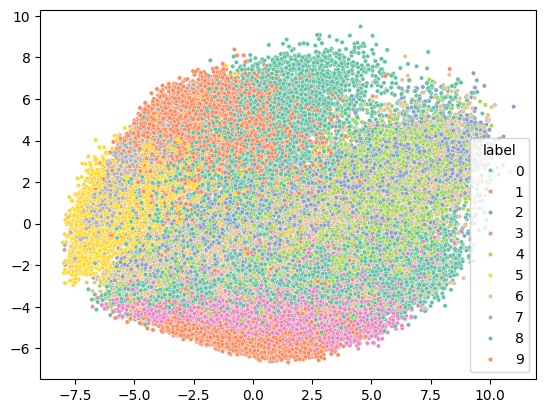

In [37]:
sns.scatterplot(x = X_train_low_dim[:,0].squeeze(), y = X_train_low_dim[:,1].squeeze(), s = 10, hue = y_train['label'], palette = 'Set2')

In [38]:
X_train.shape, y_train.shape

((59999, 784), (59999, 1))

## Test data preprocessing

X_test = pd.read_csv(r'C:\Users\DELL\Desktop\Classes\ML_Batch_474_477_482\KNN//images_test.csv')
X_test.head()

In [40]:
idx = X_test.columns
idx

Index(['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9',
       ...
       '0.507', '0.508', '0.509', '0.510', '0.511', '0.512', '0.513', '0.514',
       '0.515', '0.516'],
      dtype='object', length=784)

In [41]:
for i, ind in enumerate(idx):
  X_test.rename(columns = {ind: f'feature_{i}'}, inplace = True)

In [42]:
X_test.columns

Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9',
       ...
       'feature_774', 'feature_775', 'feature_776', 'feature_777',
       'feature_778', 'feature_779', 'feature_780', 'feature_781',
       'feature_782', 'feature_783'],
      dtype='object', length=784)

In [43]:
y_test = pd.read_csv(r'C:\Users\DELL\Desktop\Classes\ML_Batch_474_477_482\KNN//labels_test.csv')
y_test.head()

,9
0,2
1,1
2,1
3,6
4,1


In [44]:
y_test.rename(columns = {'9':'label'}, inplace = True)
y_test.columns

Index(['label'], dtype='object')

In [45]:
X_test.shape, y_test.shape

((9999, 784), (9999, 1))

In [46]:
X_test_transformed = minmax.transform(X_test)
X_test_transformed

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9999, 784))

## Model Building

In [47]:
# The squeeze() method converts a single column DataFrame into a Series.
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_transformed, y_train.squeeze())

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
# Classes known to classifier
knn.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [49]:
# Knowing the distance metric used
knn.effective_metric_

'euclidean'

In [50]:
# Number of features seen by algo during training
knn.n_features_in_

784

In [51]:
y_pred = knn.predict(X_test_transformed)
y_pred

array([2, 1, 1, ..., 8, 1, 7], shape=(9999,))

In [52]:
accuracy_score(y_test, y_pred)

0.8537853785378537

**NOT HAPPY!**

````
class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform',algorithm='auto',
leaf_size=30, p=2,metric='minkowski', metric_params=None, n_jobs=None)
````

### Understanding KNN Hyperparameters and Distance Metrics

#### 1. What is `n_neighbors`?
- **Definition:**  
  The `n_neighbors` parameter in K-Nearest Neighbors (KNN) determines how many nearby data points the algorithm examines when making predictions.
- **Role:**  
  It is a **hyperparameter** of KNN, meaning you set its value before training the model. The value of `n_neighbors` controls the "K" in KNN.

#### 2. What is `p` (when metric = 'minkowski')?
- **Definition:**  
  The `p` parameter is also a KNN hyperparameter, but it specifically influences the distance calculation when using the Minkowski metric.
- **Interpretation:**
  - `p = 1`: Uses the **Manhattan distance** (also called cityblock or L1 distance). It sums the absolute values of differences for each feature.
  - `p = 2`: Uses the **Euclidean distance** (L2 distance), which is the straight-line distance between points.
  - `p > 2`: Refers to a **generalized Minkowski distance**; higher values change the nature of the "distance" calculation.

#### 3. Other Supported Distance Metrics in KNN

KNN supports several distance functions to measure similarity between data points. Here are some commonly used ones and their corresponding functions:

| Metric Name      | Function                                 | Equivalent Parameter(s)      |
|------------------|------------------------------------------|------------------------------|
| `cityblock`      | `metrics.pairwise.manhattan_distances`   | Also called `'manhattan'`, `'l1'` |
| `cosine`         | `metrics.pairwise.cosine_distances`      |                              |
| `euclidean`      | `metrics.pairwise.euclidean_distances`   | Also called `'l2'`           |
| `haversine`      | `metrics.pairwise.haversine_distances`   |                              |
| `nan_euclidean`  | `metrics.pairwise.nan_euclidean_distances`|                             |

- **Note:**  
  - The metric you choose may affect model performance, depending on your data's characteristics.
  - Some metrics, like `haversine`, are used for geographic data (measuring distance on a sphere).
  - `l1`, `manhattan`, and `cityblock` all refer to the same distance calculation.



In [53]:
# Use manhattan distance
knn = KNeighborsClassifier(n_neighbors=3, p=1,metric='cityblock')
knn.fit(X_train_transformed, y_train.squeeze())
y_pred = knn.predict(X_test_transformed)
accuracy_score(y_test, y_pred)

0.8575857585758576

In [54]:
knn = KNeighborsClassifier(n_neighbors=3,metric='cityblock')
knn.fit(X_train_transformed, y_train.squeeze())
y_pred = knn.predict(X_test_transformed)
accuracy_score(y_test, y_pred)

0.8575857585758576

In [55]:
knn = KNeighborsClassifier(n_neighbors=3,p=1, metric='minkowski')
knn.fit(X_train_transformed, y_train.squeeze())
y_pred = knn.predict(X_test_transformed)
accuracy_score(y_test, y_pred)

0.8575857585758576